<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

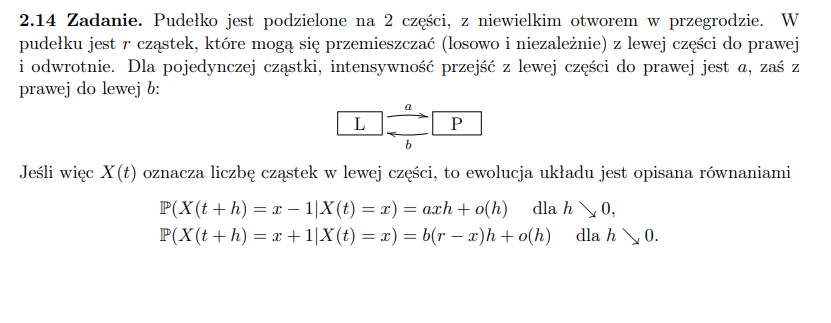

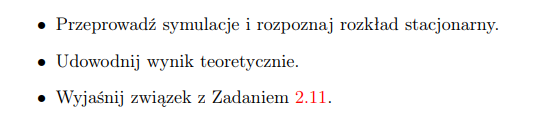

### Simulations
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
def gillespie_sampler(a, b, r, X0, T_max):
    t = [0.0]
    X = [X0]

    while t[-1] < T_max:
        current_X = X[-1]

        # updating intensivities
        rate_up = b * (r - current_X)
        rate_down = a * current_X

        total_rate = rate_up + rate_down

        if total_rate == 0:
            break

        # sampling moments of events
        dt = np.random.exponential(1.0 / total_rate)
        t.append(t[-1] + dt)

        # sampling type of event
        if np.random.rand() < rate_up / total_rate:
            X.append(current_X + 1)
        else:
            X.append(current_X - 1)

    if t[-1] > T_max:
        t[-1] = T_max
        X[-1] = X[-2]

    return np.array(t), np.array(X)

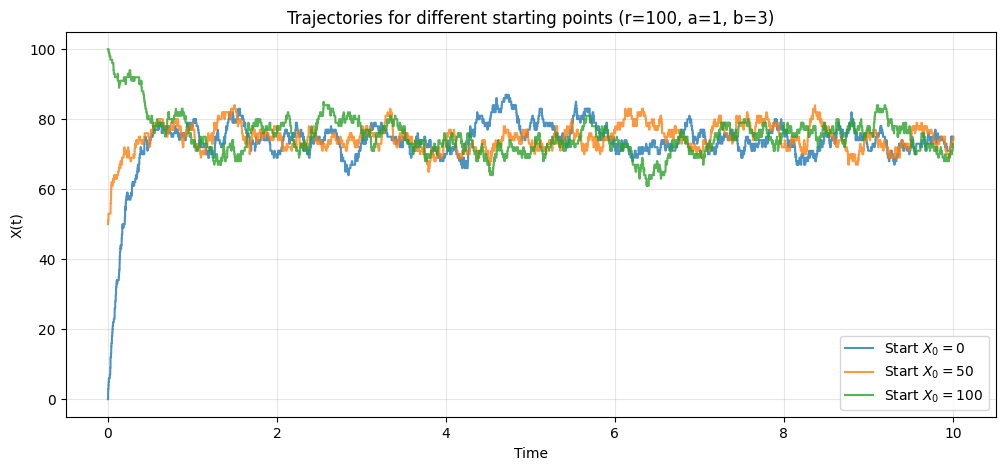

In [3]:
r = 100
a = 1
b = 3
T_max = 10

# plotting for different starting points
plt.figure(figsize=(12, 5))
for X0 in [0, 50, 100]:
    t_vals, X_vals = gillespie_sampler(a, b, r, X0, T_max)
    plt.step(t_vals, X_vals, where='post', alpha=0.8, linewidth=1.5, label=f'Start $X_0={X0}$')

plt.title(f'Trajectories for different starting points (r={r}, a={a}, b={b})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_7188/1092705903.py:22: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Estimated stationary distribution $\pi(x)$')


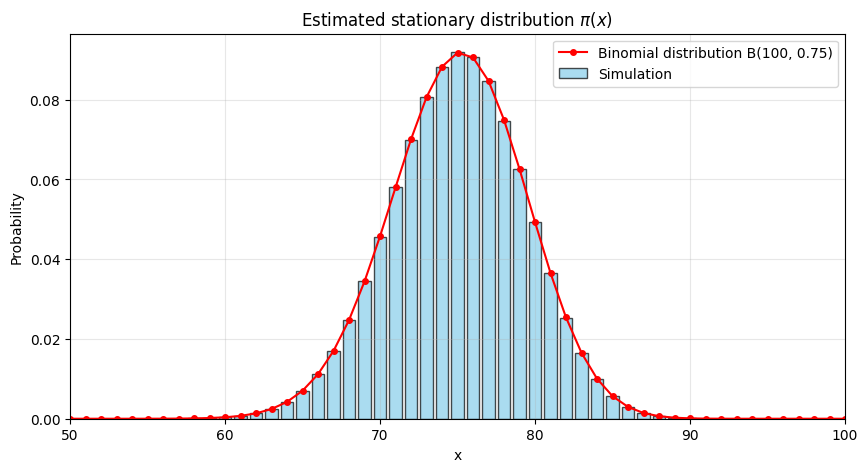

In [6]:
# long trajectory for recognizing stationary distribution
t_long = 100000
t_l, X_l = gillespie_sampler(a, b, r, X0, t_long)

holding_times = np.diff(t_l)
visited_states = X_l[:-1]

# summing time in states
time_in_states = np.bincount(visited_states, weights=holding_times, minlength=r+1)
pi_est = time_in_states / t_long

plt.figure(figsize=(10, 5))
states = np.arange(r + 1)
plt.bar(states, pi_est, color='skyblue', edgecolor='black', alpha=0.7, label='Simulation')

# recognizing Binomial Distribution
p_teoret = b / (a + b)
expected_eq = r * p_teoret
binom_pmf = stats.binom.pmf(states, r, p_teoret)
plt.plot(states, binom_pmf, 'ro-', markersize=4, label=f'Binomial distribution B({r}, {p_teoret:.2f})')

plt.title('Estimated stationary distribution $\pi(x)$')
plt.xlim(max(0, expected_eq - 25), min(r, expected_eq + 25))
plt.xlabel('x')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Stationary distribution
---
Let us observe that this is a birth-death process on the state space $x \in \{0, 1, \dots, r\}$ with transition rates:

$$q_{x, x+1} = b(r - x)$$
$$q_{x, x-1} = ax$$

To find the stationary distribution $\pi(x)$, we use the
balance equation:
$$\pi(x) \cdot q_{x, x+1} = \pi(x+1) \cdot q_{x+1, x}$$

Substitute our specific rates into the equation:
$$\pi(x) \cdot b(r - x) = \pi(x+1) \cdot a(x + 1)$$

$$\pi(x+1) = \frac{b}{a} \cdot \frac{r - x}{x + 1} \cdot \pi(x)$$

Applying this recursively down to $x=0$, we get:
$$\pi(x) = \left(\frac{b}{a}\right)^x \frac{r \cdot (r-1) \cdots (r-x+1)}{x!} \pi(0) =\binom{r}{x} \left(\frac{b}{a}\right)^x \pi(0)$$

Since $\sum_{n=0}^∞\pi(n) = 1$:

$$\sum_{x=0}^{r} \binom{r}{x} \left(\frac{b}{a}\right)^x \pi(0) = 1$$

$$\pi(0) \left(\frac{a + b}{a}\right)^r = 1 \implies \pi(0) = \left(\frac{a}{a+b}\right)^r$$

Finally, we obtain:

$$\pi(x) = \binom{r}{x} \left(\frac{b}{a}\right)^x \left(\frac{a}{a+b}\right)^r = \binom{r}{x} \left(\frac{b}{a+b}\right)^x \left(\frac{a}{a+b}\right)^{r-x},$$

which is exactly the probability mass function of the Binomial distribution $B(r, p)$ with parameters $n = r$ and $p = \frac{b}{a+b}$.

### Connection with Exercise 2.11
---

Exercise 2.14 is actually a direct extension of Exercise 2.11. While Exercise 2.11 models the behavior of a single particle simply jumping between two states, Exercise 2.14 models a system of $r$ independent particles. If we track just one single particle in Exercise 2.14, it follows the exact same Markov process described in Exercise 2.11 (with $\alpha=a$ and $\beta=b$). From 2.11, we know that a single particle's stationary probability of being in the left box is $p = \frac{b}{a+b}$.